In [1]:
import watermark
pkg_versions = watermark.watermark(
    packages="requests,pandas,tqdm,geopandas")
print(pkg_versions)

requests : 2.32.5
pandas   : 1.5.3
tqdm     : 4.67.1
geopandas: 1.0.1



In [2]:
import pandas as pd
df = pd.read_excel("부산_구군별_연도별_방문자수_2021_2025_final.xlsx")

In [3]:
df

,연도,구군,현지인,외지인,외국인
0,2021,강서구,22610007.0,32449991.0,75584.91
1,2022,강서구,27916252.0,37013578.0,244725.17
2,2023,강서구,30254374.5,39971333.5,2704399.59
3,2024,강서구,30329530.0,41067383.0,4030042.58
4,2025,강서구,33443718.0,44556991.5,5571301.93
...,...,...,...,...,...
75,2021,해운대구,83514424.0,60211343.5,56267.99
76,2022,해운대구,87410834.0,66520097.0,237863.34
77,2023,해운대구,86758206.5,67603182.5,2004681.71
78,2024,해운대구,87120813.5,68279911.0,3059824.79


In [4]:
pivot_2025 = (
    df[df['연도'] == 2025]
    .pivot_table(
        index='구군',
        values=['현지인', '외지인', '외국인'],
        aggfunc='sum'
    )
    .reset_index()
)

In [5]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/home/DL/.local/share/fonts/KoPubWorld/KoPubWorld Dotum Medium.ttf"

# 현재 Python 프로세스에 폰트 등록
fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()
print(font_name)

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

KoPubWorldDotum


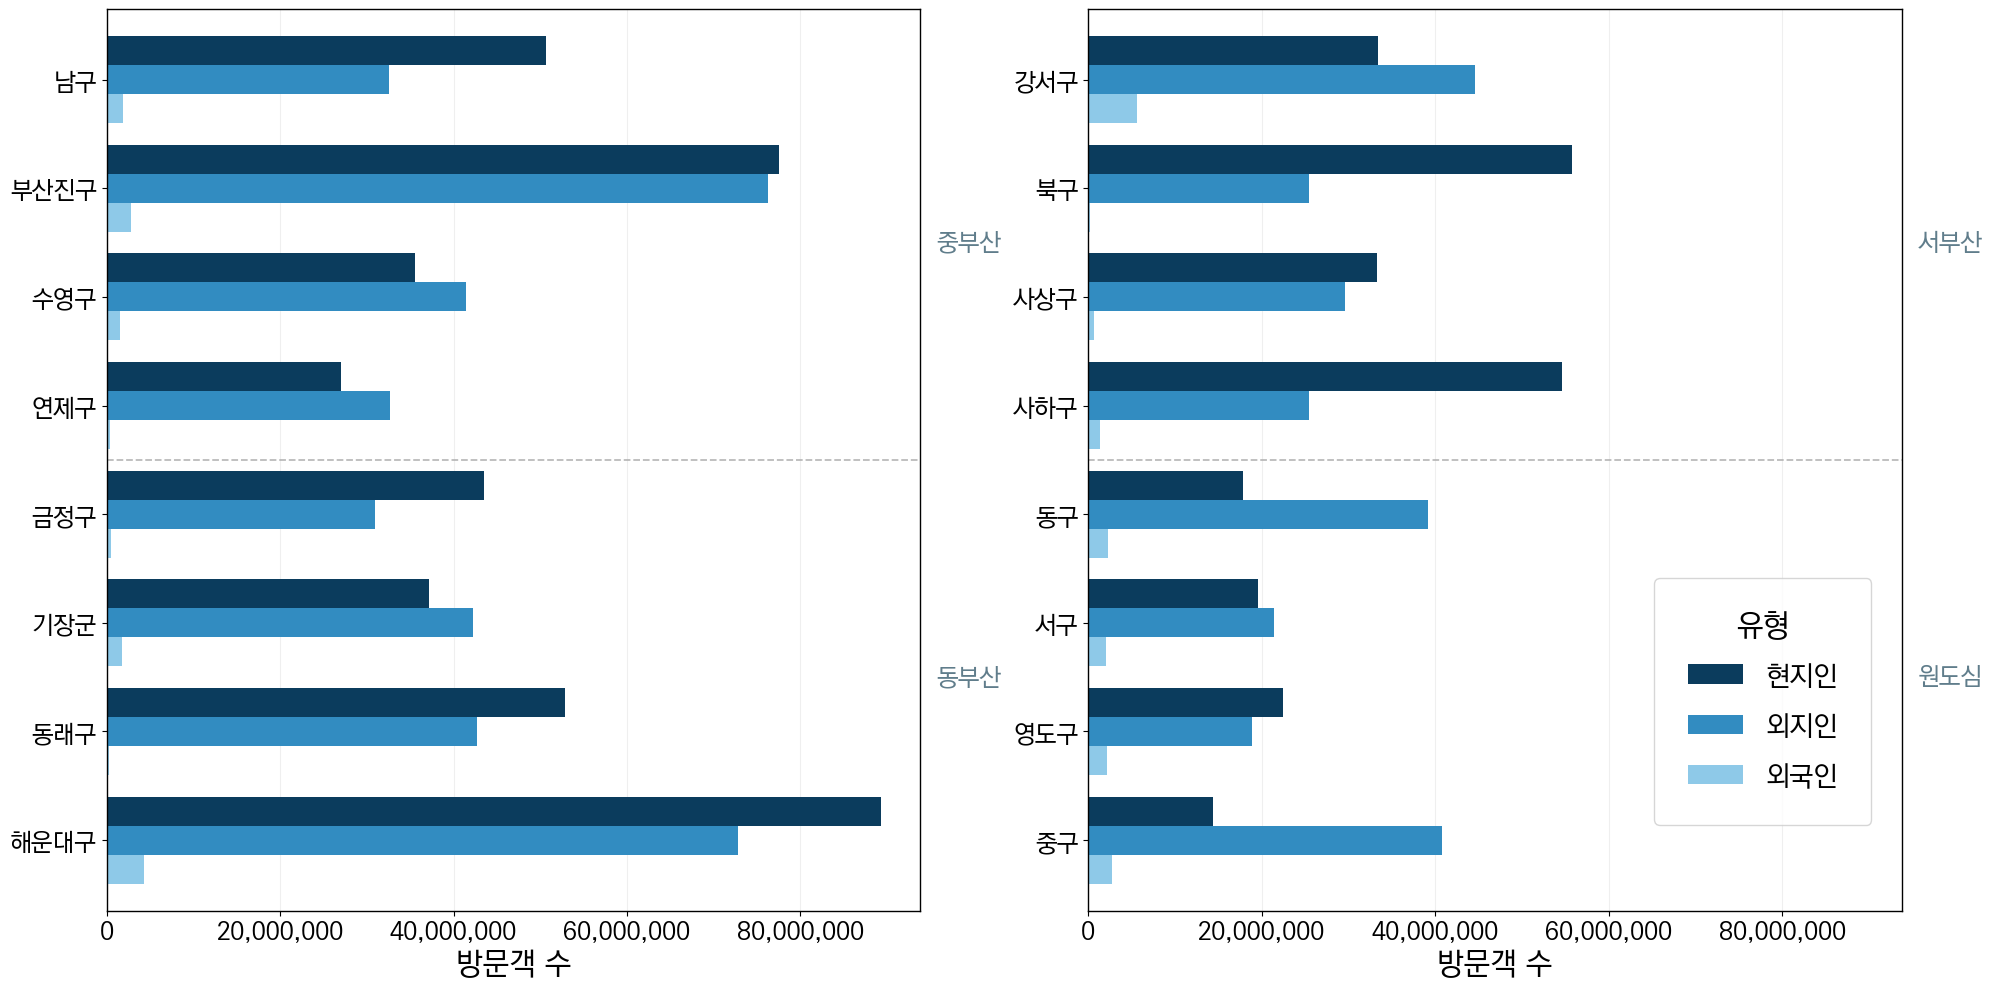

In [7]:
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. 4개 권역 설정
# =========================================================

region_map = {
    # 원도심
    "중구": "원도심",
    "동구": "원도심",
    "서구": "원도심",
    "영도구": "원도심",

    # 중부산
    "남구": "중부산",
    "부산진구": "중부산",
    "수영구": "중부산",
    "연제구": "중부산",

    # 서부산
    "강서구": "서부산",
    "북구": "서부산",
    "사상구": "서부산",
    "사하구": "서부산",

    # 동부산
    "금정구": "동부산",
    "기장군": "동부산",
    "동래구": "동부산",
    "해운대구": "동부산",
}


# =========================================================
# 2. 데이터 복사 + 권역 추가
# =========================================================

d = pivot_2025.copy()

d["권역"] = d["구군"].map(region_map)


# =========================================================
# 3. 권역 순서
#
# 왼쪽  : 중부산 → 동부산
# 오른쪽: 서부산 → 원도심
# =========================================================

region_order = [
    "중부산",
    "동부산",
    "서부산",
    "원도심"
]

d["권역"] = pd.Categorical(
    d["권역"],
    categories=region_order,
    ordered=True
)


# =========================================================
# 4. 권역별 + 구군 가나다순 정렬
# =========================================================

d = (
    d
    .sort_values(
        ["권역", "구군"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)


# =========================================================
# 5. 좌우 데이터 분리
#
# 왼쪽  : 중부산 + 동부산
# 오른쪽: 서부산 + 원도심
# =========================================================

df1 = (
    d[
        d["권역"].isin([
            "중부산",
            "동부산"
        ])
    ]
    .copy()
    .reset_index(drop=True)
)

df2 = (
    d[
        d["권역"].isin([
            "서부산",
            "원도심"
        ])
    ]
    .copy()
    .reset_index(drop=True)
)


# =========================================================
# 6. 그래프
# =========================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(20, 10),
    sharex=True
)


colors = [
    "#0B3C5D",   # 현지인
    "#328CC1",   # 외지인
    "#8EC9E8"    # 외국인
]


# =========================================================
# 7. 왼쪽 그래프
# =========================================================

df1.plot(
    x="구군",
    y=[
        "현지인",
        "외지인",
        "외국인"
    ],
    kind="barh",
    ax=ax1,
    color=colors,
    width=0.8
)


# =========================================================
# 8. 오른쪽 그래프
# =========================================================

df2.plot(
    x="구군",
    y=[
        "현지인",
        "외지인",
        "외국인"
    ],
    kind="barh",
    ax=ax2,
    color=colors,
    width=0.8
)


# =========================================================
# 9. 공통 설정
# =========================================================

for ax in [ax1, ax2]:

    ax.set_xlabel(
        "방문객 수",
        fontsize=22,
        fontweight="bold"
    )

    ax.set_ylabel("")

    ax.tick_params(
        axis="x",
        labelsize=18
    )

    ax.tick_params(
        axis="y",
        labelsize=18
    )

    # 천 단위 콤마
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda x, _: f"{x:,.0f}"
        )
    )

    ax.grid(
        axis="x",
        alpha=0.2
    )

    ax.set_axisbelow(True)

    # 위 → 아래
    ax.invert_yaxis()


# =========================================================
# 10. 권역 구분선 + 권역명
# =========================================================

def add_region_info(ax, data, regions):

    for region in regions:

        idx = data.index[
            data["권역"] == region
        ].tolist()

        if not idx:
            continue

        start = min(idx)
        end = max(idx)


        # -------------------------------------------------
        # 권역 사이 점선
        # -------------------------------------------------

        if start > 0:

            ax.axhline(
                y=start - 0.5,
                color="#9E9E9E",
                linewidth=1.3,
                linestyle="--",
                alpha=0.7,
                zorder=0
            )


        # -------------------------------------------------
        # 권역명
        # -------------------------------------------------

        center = (start + end) / 2

        ax.text(
            1.02,
            center,
            region,

            transform=ax.get_yaxis_transform(),

            ha="left",
            va="center",

            fontsize=18,
            fontweight="bold",

            color="#607D8B"
        )


# =========================================================
# 11. 권역 표시
# =========================================================

# 왼쪽
add_region_info(
    ax1,
    df1,
    [
        "중부산",
        "동부산"
    ]
)

# 오른쪽
add_region_info(
    ax2,
    df2,
    [
        "서부산",
        "원도심"
    ]
)


# =========================================================
# 12. 범례
# =========================================================

# 왼쪽 범례 제거
if ax1.get_legend() is not None:
    ax1.get_legend().remove()


# 오른쪽 기존 범례 제거
if ax2.get_legend() is not None:
    ax2.get_legend().remove()


# ---------------------------------------------------------
# 오른쪽 그래프의 빈 공간에 범례 배치
#
# 서부산/원도심은 막대가 상대적으로 왼쪽에 몰려 있어서
# 오른쪽 아래 공간을 활용
# ---------------------------------------------------------

ax2.legend(
    title="유형",

    fontsize=20,
    title_fontsize=22,

    markerscale=1.5,

    borderpad=1.2,
    labelspacing=0.8,

    loc="lower right",

    # 조금 위쪽으로 조정
    bbox_to_anchor=(0.98, 0.08),

    frameon=True
)


# =========================================================
# 13. 바깥 테두리 유지
# =========================================================

for ax in [ax1, ax2]:

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)


# =========================================================
# 14. 패널 사이 간격
# =========================================================

plt.subplots_adjust(
    wspace=0.35
)


# =========================================================
# 15. 레이아웃
# =========================================================

plt.tight_layout()


# =========================================================
# 16. 저장
# =========================================================

plt.savefig(
    "2025_구군별_방문객유형_4권역.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

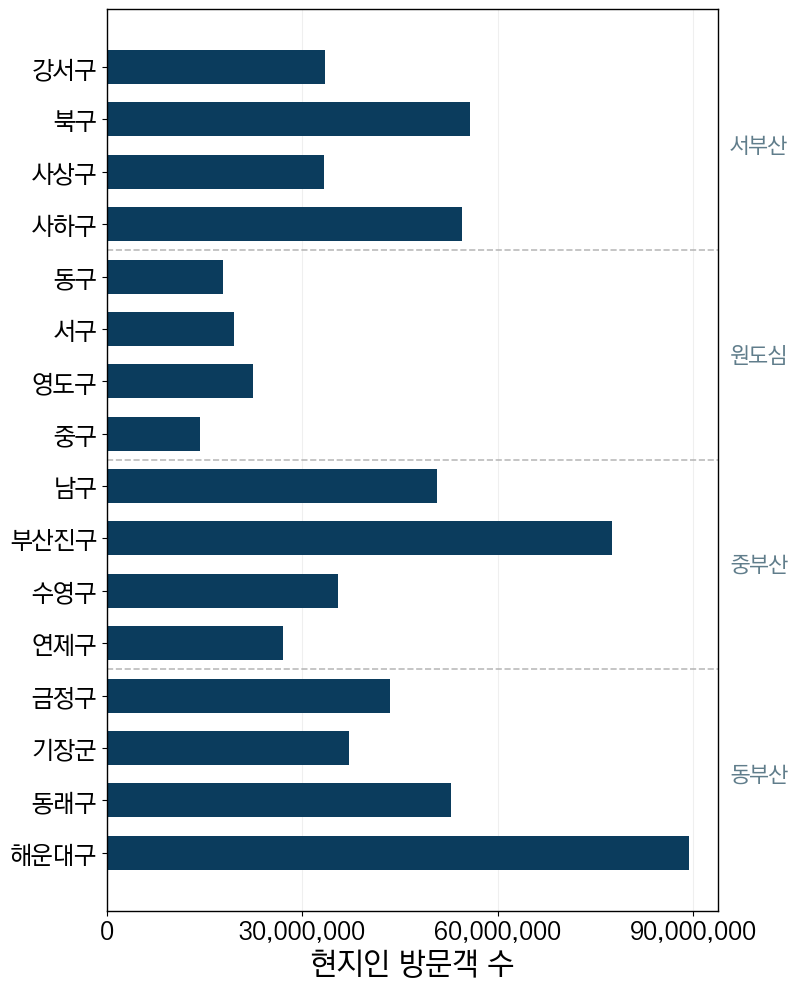

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator


# =========================================================
# 1. 4개 권역 설정
# =========================================================

region_map = {
    # 원도심
    "중구": "원도심",
    "동구": "원도심",
    "서구": "원도심",
    "영도구": "원도심",

    # 중부산
    "남구": "중부산",
    "부산진구": "중부산",
    "수영구": "중부산",
    "연제구": "중부산",

    # 서부산
    "강서구": "서부산",
    "북구": "서부산",
    "사상구": "서부산",
    "사하구": "서부산",

    # 동부산
    "금정구": "동부산",
    "기장군": "동부산",
    "동래구": "동부산",
    "해운대구": "동부산",
}


# =========================================================
# 2. 2025년 데이터
# =========================================================

local_2025 = (
    df[df["연도"] == 2025]
    .copy()
)

local_2025["권역"] = local_2025["구군"].map(region_map)


# =========================================================
# 3. 권역 순서 설정
# =========================================================

region_order = [
    "서부산",
    "원도심",
    "중부산",
    "동부산"
]

local_2025["권역"] = pd.Categorical(
    local_2025["권역"],
    categories=region_order,
    ordered=True
)


# =========================================================
# 4. 권역별 → 구군 가나다순
# =========================================================

local_2025 = (
    local_2025
    .sort_values(
        ["권역", "구군"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)


# =========================================================
# 5. 그래프
# =========================================================

fig, ax = plt.subplots(
    figsize=(9, 10)
)

bars = ax.barh(
    local_2025["구군"],
    local_2025["현지인"],
    color="#0B3C5D",
    height=0.65
)


# =========================================================
# 6. 위 → 아래 순서
#
# 서부산
# 원도심
# 중부산
# 동부산
# =========================================================

ax.invert_yaxis()


# =========================================================
# 7. 권역 구분선 + 권역명
# =========================================================

for region in region_order:

    idx = local_2025.index[
        local_2025["권역"] == region
    ].tolist()

    if not idx:
        continue

    start = min(idx)
    end = max(idx)


    # -----------------------------------------------------
    # 권역 사이 점선
    # -----------------------------------------------------

    if start > 0:

        ax.axhline(
            y=start - 0.5,
            color="#9E9E9E",
            linewidth=1.2,
            linestyle="--",
            alpha=0.7,
            zorder=0
        )


    # -----------------------------------------------------
    # 오른쪽 권역명
    # -----------------------------------------------------

    center = (start + end) / 2

    ax.text(
        1.02,
        center,
        region,

        transform=ax.get_yaxis_transform(),

        ha="left",
        va="center",

        fontsize=16,
        fontweight="bold",

        color="#607D8B"
    )


# =========================================================
# 8. 축 설정
# =========================================================

ax.set_xlabel(
    "현지인 방문객 수",
    fontsize=22,
    fontweight="bold"
)

ax.set_ylabel("")


# =========================================================
# 9. 틱 라벨
# =========================================================

ax.tick_params(
    axis="x",
    labelsize=18
)

ax.tick_params(
    axis="y",
    labelsize=18
)


# =========================================================
# 10. X축 틱 간격
# 30,000,000
# =========================================================

ax.xaxis.set_major_locator(
    MultipleLocator(30_000_000)
)


# =========================================================
# 11. 숫자 콤마
# =========================================================

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _: f"{x:,.0f}"
    )
)


# =========================================================
# 12. 보조선
# =========================================================

ax.grid(
    axis="x",
    alpha=0.2
)

ax.set_axisbelow(True)


# =========================================================
# 13. 바깥 테두리 유지
# =========================================================

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)


# =========================================================
# 14. 레이아웃
# 권역명 표시 공간 확보
# =========================================================

plt.tight_layout(
    rect=[0, 0, 0.90, 1]
)


# =========================================================
# 15. 저장
# =========================================================

plt.savefig(
    "2025_구군별_현지인_4권역.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

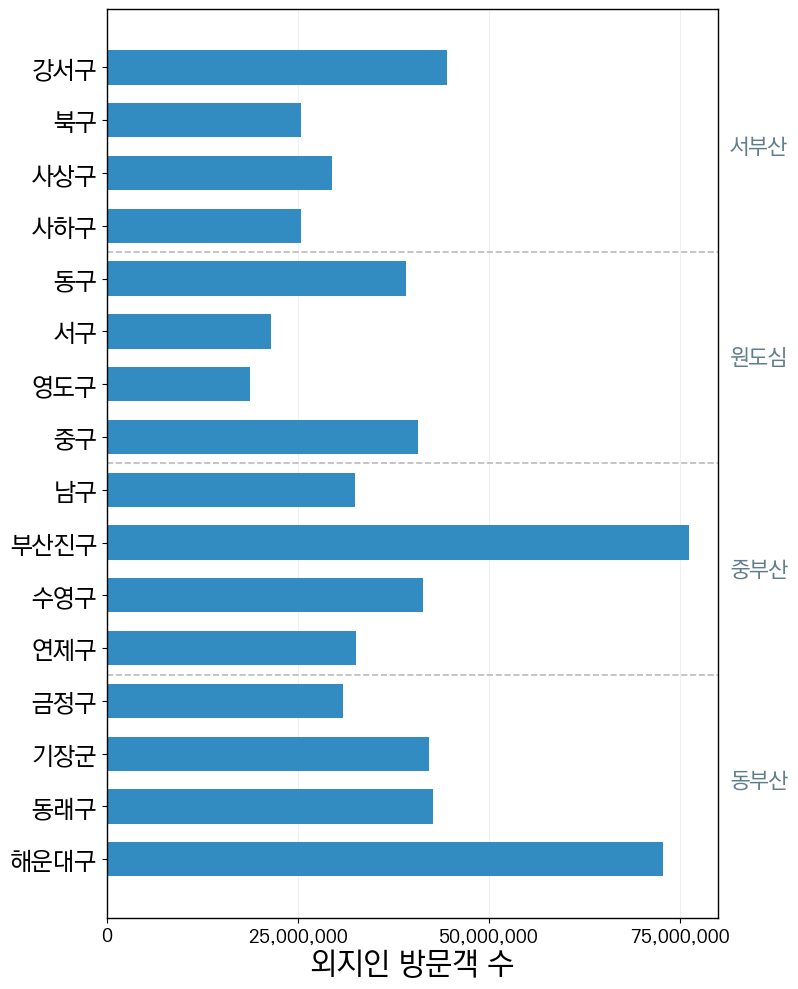

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator


# =========================================================
# 1. 4개 권역 설정
# =========================================================

region_map = {
    # 원도심
    "중구": "원도심",
    "동구": "원도심",
    "서구": "원도심",
    "영도구": "원도심",

    # 중부산
    "남구": "중부산",
    "부산진구": "중부산",
    "수영구": "중부산",
    "연제구": "중부산",

    # 서부산
    "강서구": "서부산",
    "북구": "서부산",
    "사상구": "서부산",
    "사하구": "서부산",

    # 동부산
    "금정구": "동부산",
    "기장군": "동부산",
    "동래구": "동부산",
    "해운대구": "동부산",
}


# =========================================================
# 2. 2025년 데이터 + 권역 추가
# =========================================================

local_2025 = (
    df[df["연도"] == 2025]
    .copy()
)

local_2025["권역"] = local_2025["구군"].map(region_map)


# =========================================================
# 3. 권역 순서
# =========================================================

region_order = [
    "서부산",
    "원도심",
    "중부산",
    "동부산"
]

local_2025["권역"] = pd.Categorical(
    local_2025["권역"],
    categories=region_order,
    ordered=True
)


# =========================================================
# 4. 권역별 → 구군 가나다순
# =========================================================

local_2025 = (
    local_2025
    .sort_values(
        ["권역", "구군"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)


# =========================================================
# 5. 그래프
# =========================================================

fig, ax = plt.subplots(
    figsize=(9, 10)
)

ax.barh(
    local_2025["구군"],
    local_2025["외지인"],
    color="#328CC1",
    height=0.65
)


# =========================================================
# 6. 위 → 아래
# 서부산 → 원도심 → 중부산 → 동부산
# =========================================================

ax.invert_yaxis()


# =========================================================
# 7. 권역 구분선 + 권역명
# =========================================================

for region in region_order:

    idx = local_2025.index[
        local_2025["권역"] == region
    ].tolist()

    if not idx:
        continue

    start = min(idx)
    end = max(idx)


    # -----------------------------------------------------
    # 권역 사이 점선
    # -----------------------------------------------------

    if start > 0:

        ax.axhline(
            y=start - 0.5,
            color="#9E9E9E",
            linewidth=1.2,
            linestyle="--",
            alpha=0.7,
            zorder=0
        )


    # -----------------------------------------------------
    # 오른쪽 권역명
    # -----------------------------------------------------

    center = (start + end) / 2

    ax.text(
        1.02,
        center,
        region,

        transform=ax.get_yaxis_transform(),

        ha="left",
        va="center",

        fontsize=16,
        fontweight="bold",

        color="#607D8B"
    )


# =========================================================
# 8. 축 설정
# =========================================================

ax.set_xlabel(
    "외지인 방문객 수",
    fontsize=22,
    fontweight="bold"
)

ax.set_ylabel("")


# =========================================================
# 9. 틱 라벨
# =========================================================

ax.tick_params(
    axis="x",
    labelsize=14
)

ax.tick_params(
    axis="y",
    labelsize=18
)


# =========================================================
# 10. X축 틱 간격 = 2,500만
# =========================================================

ax.xaxis.set_major_locator(
    MultipleLocator(25_000_000)
)


# =========================================================
# 11. 숫자 콤마 표시
# =========================================================

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _: f"{x:,.0f}"
    )
)


# =========================================================
# 12. 보조선
# =========================================================

ax.grid(
    axis="x",
    alpha=0.2
)

ax.set_axisbelow(True)


# =========================================================
# 13. 바깥 테두리 유지
# =========================================================

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)


# =========================================================
# 14. 레이아웃
# 오른쪽 권역명 공간 확보
# =========================================================

plt.tight_layout(
    rect=[0, 0, 0.90, 1]
)


# =========================================================
# 15. 저장
# =========================================================

plt.savefig(
    "2025_구군별_외지인_4권역.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

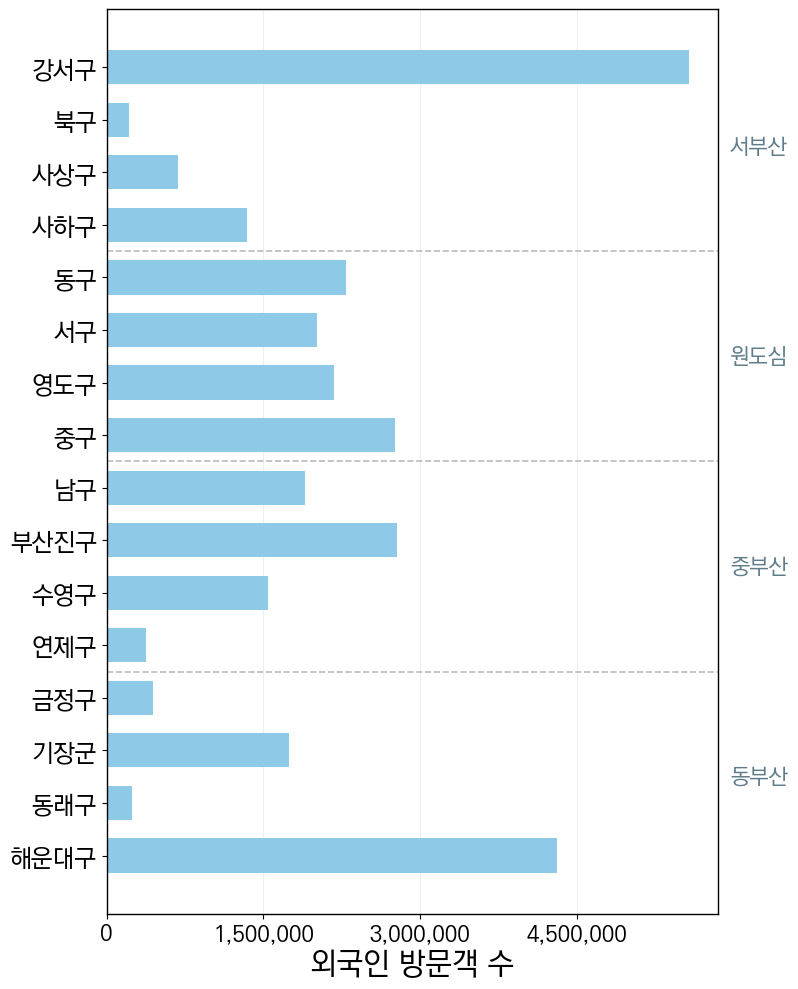

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator


# =========================================================
# 1. 4개 권역 설정
# =========================================================

region_map = {
    # 원도심
    "중구": "원도심",
    "동구": "원도심",
    "서구": "원도심",
    "영도구": "원도심",

    # 중부산
    "남구": "중부산",
    "부산진구": "중부산",
    "수영구": "중부산",
    "연제구": "중부산",

    # 서부산
    "강서구": "서부산",
    "북구": "서부산",
    "사상구": "서부산",
    "사하구": "서부산",

    # 동부산
    "금정구": "동부산",
    "기장군": "동부산",
    "동래구": "동부산",
    "해운대구": "동부산",
}


# =========================================================
# 2. 2025년 데이터 + 권역 추가
# =========================================================

local_2025 = (
    df[df["연도"] == 2025]
    .copy()
)

local_2025["권역"] = local_2025["구군"].map(region_map)


# =========================================================
# 3. 권역 순서
# =========================================================

region_order = [
    "서부산",
    "원도심",
    "중부산",
    "동부산"
]

local_2025["권역"] = pd.Categorical(
    local_2025["권역"],
    categories=region_order,
    ordered=True
)


# =========================================================
# 4. 권역별 → 구군 가나다순
# =========================================================

local_2025 = (
    local_2025
    .sort_values(
        ["권역", "구군"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)


# =========================================================
# 5. 그래프
# =========================================================

fig, ax = plt.subplots(
    figsize=(9, 10)
)

ax.barh(
    local_2025["구군"],
    local_2025["외국인"],
    color="#8EC9E8",
    height=0.65
)


# =========================================================
# 6. 위 → 아래
#
# 서부산 → 원도심 → 중부산 → 동부산
# =========================================================

ax.invert_yaxis()


# =========================================================
# 7. 권역 구분선 + 권역명
# =========================================================

for region in region_order:

    idx = local_2025.index[
        local_2025["권역"] == region
    ].tolist()

    if not idx:
        continue

    start = min(idx)
    end = max(idx)


    # -----------------------------------------------------
    # 권역 사이 점선
    # -----------------------------------------------------

    if start > 0:

        ax.axhline(
            y=start - 0.5,
            color="#9E9E9E",
            linewidth=1.2,
            linestyle="--",
            alpha=0.7,
            zorder=0
        )


    # -----------------------------------------------------
    # 오른쪽 권역명
    # -----------------------------------------------------

    center = (start + end) / 2

    ax.text(
        1.02,
        center,
        region,

        transform=ax.get_yaxis_transform(),

        ha="left",
        va="center",

        fontsize=16,
        fontweight="bold",

        color="#607D8B"
    )


# =========================================================
# 8. 축 설정
# =========================================================

ax.set_xlabel(
    "외국인 방문객 수",
    fontsize=22,
    fontweight="bold"
)

ax.set_ylabel("")


# =========================================================
# 9. 틱 라벨
# =========================================================

ax.tick_params(
    axis="x",
    labelsize=16
)

ax.tick_params(
    axis="y",
    labelsize=18
)


# =========================================================
# 10. X축 틱 간격 = 150만
# =========================================================

ax.xaxis.set_major_locator(
    MultipleLocator(1_500_000)
)


# =========================================================
# 11. 숫자 콤마 표시
# =========================================================

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _: f"{x:,.0f}"
    )
)


# =========================================================
# 12. 보조선
# =========================================================

ax.grid(
    axis="x",
    alpha=0.2
)

ax.set_axisbelow(True)


# =========================================================
# 13. 바깥 테두리 유지
# =========================================================

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)


# =========================================================
# 14. 레이아웃
# 오른쪽 권역명 공간 확보
# =========================================================

plt.tight_layout(
    rect=[0, 0, 0.90, 1]
)


# =========================================================
# 15. 저장
# =========================================================

plt.savefig(
    "2025_구군별_외국인_4권역.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

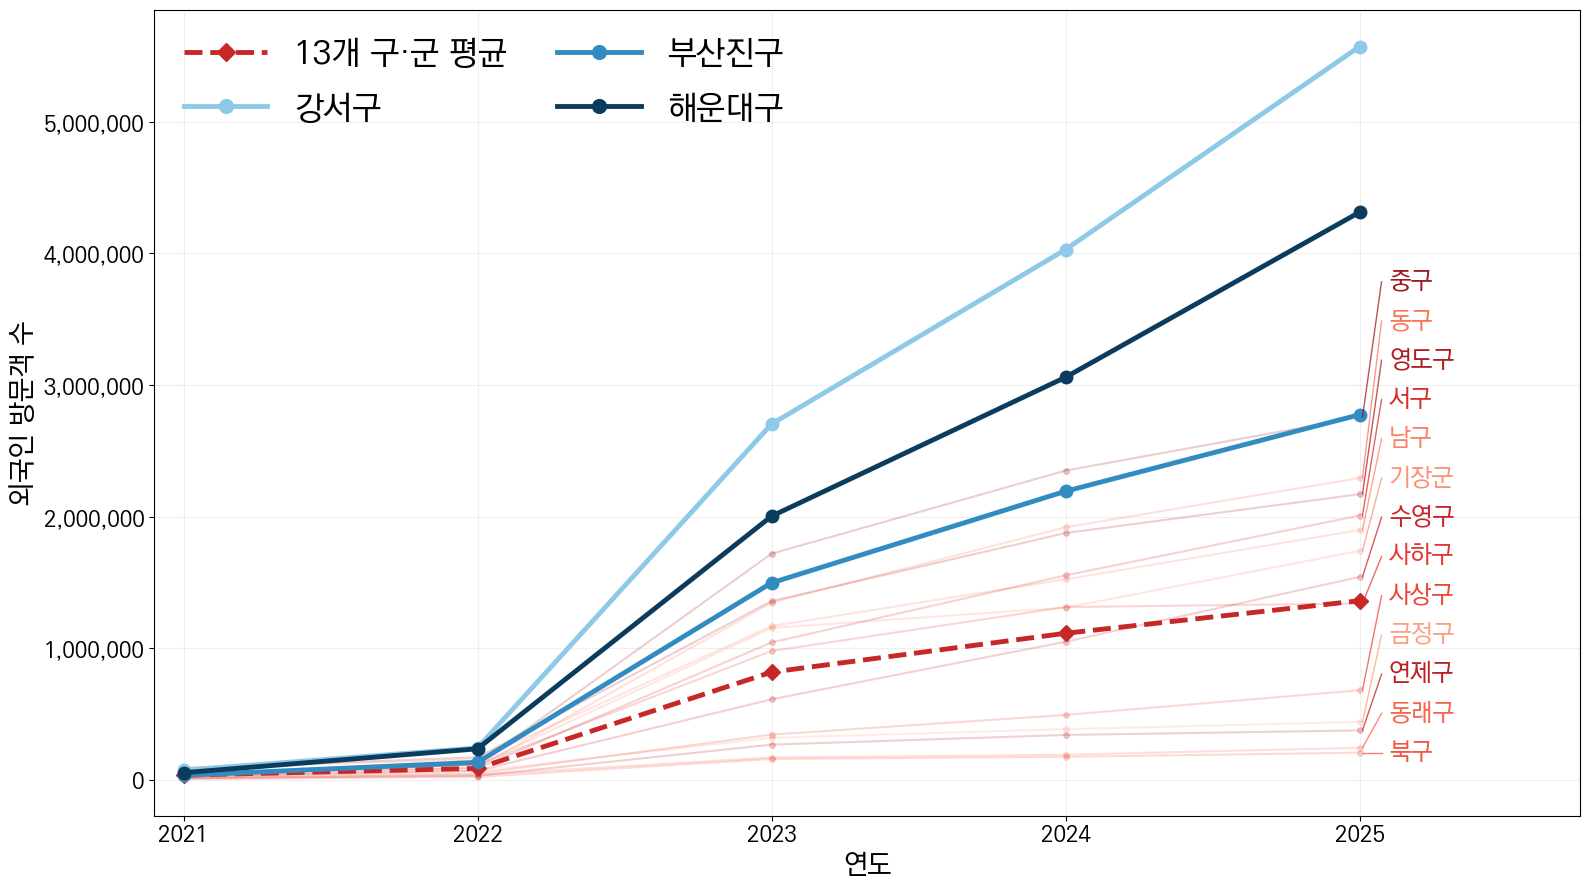

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


fig, ax = plt.subplots(figsize=(16, 9))


# =========================================================
# 1. 강조할 3개 구
# =========================================================

main_gu = [
    '강서구',
    '부산진구',
    '해운대구'
]


# =========================================================
# 2. 주요 3개 구 색상
# =========================================================

blue_colors = {
    '강서구': '#8EC9E8',
    '부산진구': '#328CC1',
    '해운대구': '#0B3C5D'
}


# =========================================================
# 3. 전체 구군
# =========================================================

gu_list = sorted(df['구군'].unique())


# =========================================================
# 4. 주요 3개 구 제외
# =========================================================

other_gu = [
    gu
    for gu in gu_list
    if gu not in main_gu
]


# =========================================================
# 5. 나머지 구군 색상
# =========================================================

cmap = plt.cm.Reds

red_colors = [
    cmap(
        0.35
        + 0.55 * i / max(len(other_gu) - 1, 1)
    )
    for i in range(len(other_gu))
]

red_color_dict = dict(
    zip(other_gu, red_colors)
)


# =========================================================
# 6. 나머지 13개 구군 선
# =========================================================

for gu in other_gu:

    temp = (
        df[df['구군'] == gu]
        .sort_values('연도')
    )

    ax.plot(
        temp['연도'],
        temp['외국인'],

        marker='o',
        markersize=4,

        linewidth=1.5,

        color=red_color_dict[gu],

        label='_nolegend_',

        # 개별선은 연하게
        alpha=0.20,

        zorder=2
    )


# =========================================================
# 7. 13개 구군 평균
# =========================================================

avg_other = (
    df[
        ~df['구군'].isin(main_gu)
    ]
    .groupby(
        '연도',
        as_index=False
    )['외국인']
    .mean()
    .sort_values('연도')
)


# =========================================================
# 8. 평균선
# =========================================================

ax.plot(
    avg_other['연도'],
    avg_other['외국인'],

    marker='D',
    markersize=8,

    linewidth=3.5,
    linestyle='--',

    color='#C62828',

    label='13개 구·군 평균',

    alpha=1.0,

    zorder=9
)


# =========================================================
# 9. 주요 3개 구
# =========================================================

for gu in main_gu:

    temp = (
        df[df['구군'] == gu]
        .sort_values('연도')
    )

    ax.plot(
        temp['연도'],
        temp['외국인'],

        marker='o',
        markersize=9,

        linewidth=3.5,

        color=blue_colors[gu],

        label=gu,

        alpha=1.0,

        zorder=10
    )


# =========================================================
# 10. 축 설정을 먼저 적용
# 레이블 간격 계산 전에 축 범위를 확정
# =========================================================

ax.set_xticks([
    2021,
    2022,
    2023,
    2024,
    2025
])

ax.set_xlim(
    2020.9,
    2025.75
)

ax.set_xlabel(
    '연도',
    fontsize=20,
    fontweight='bold'
)

ax.set_ylabel(
    '외국인 방문객 수',
    fontsize=20,
    fontweight='bold'
)

ax.tick_params(
    axis='x',
    labelsize=16
)

ax.tick_params(
    axis='y',
    labelsize=16
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, _: f'{x:,.0f}'
    )
)


# =========================================================
# 11. 2025년 나머지 13개 구군
# =========================================================

label_df = (
    df[
        (df['연도'] == 2025)
        & (~df['구군'].isin(main_gu))
    ][
        ['구군', '외국인']
    ]
    .copy()
    .sort_values('외국인')
    .reset_index(drop=True)
)


# =========================================================
# 12. 레이블 폰트 크기
# =========================================================

label_fontsize = 18


# =========================================================
# 13. 현재 Y축 범위
# =========================================================

ymin, ymax = ax.get_ylim()

y_range = ymax - ymin


# =========================================================
# 14. 폰트 크기를 기준으로 최소 Y 간격 자동 계산
#
# fontsize는 pt 단위
# figure 높이와 axes 높이를 이용해서
# 실제 데이터 좌표 간격으로 변환
# =========================================================

fig.canvas.draw()

bbox = ax.get_window_extent()

axes_height_px = bbox.height

dpi = fig.dpi


# 폰트 18pt를 pixel로 변환
font_height_px = (
    label_fontsize
    * dpi
    / 72
)


# 글자 사이에 약간 여백 추가
required_px = font_height_px * 1.35


# pixel → 데이터 좌표
min_gap = (
    required_px
    / axes_height_px
    * y_range
)


# =========================================================
# 15. 실제 Y값
# =========================================================

actual_y = (
    label_df['외국인']
    .to_numpy(dtype=float)
)

label_y = actual_y.copy()


# =========================================================
# 16. 아래 → 위 방향으로 최소 간격 확보
# =========================================================

for i in range(1, len(label_y)):

    if label_y[i] - label_y[i - 1] < min_gap:

        label_y[i] = (
            label_y[i - 1]
            + min_gap
        )


# =========================================================
# 17. 위쪽 한계를 넘어가면 아래로 이동
# =========================================================

top_limit = ymax - min_gap * 0.5

if label_y[-1] > top_limit:

    label_y -= (
        label_y[-1]
        - top_limit
    )


# =========================================================
# 18. 아래쪽도 한계 확인
# =========================================================

bottom_limit = ymin + min_gap * 0.5

if label_y[0] < bottom_limit:

    label_y += (
        bottom_limit
        - label_y[0]
    )


# =========================================================
# 19. 다시 위 → 아래 방향으로 조정
#
# 위/아래 이동 때문에 생길 수 있는 간격 문제 보정
# =========================================================

for i in range(len(label_y) - 2, -1, -1):

    if label_y[i + 1] - label_y[i] < min_gap:

        label_y[i] = (
            label_y[i + 1]
            - min_gap
        )


# =========================================================
# 20. 레이블 위치
# =========================================================

label_x = 2025.10


# =========================================================
# 21. 레이블 + 연결선
# =========================================================

for i, row in label_df.iterrows():

    gu = row['구군']

    y_actual = row['외국인']
    y_text = label_y[i]

    color = red_color_dict[gu]


    # -----------------------------------------------------
    # 실제 2025년 값에서 레이블까지 연결
    # -----------------------------------------------------

    ax.plot(
        [
            2025.01,
            label_x - 0.025
        ],
        [
            y_actual,
            y_text
        ],

        color=color,

        linewidth=1.0,

        alpha=0.70,

        zorder=15
    )


    # -----------------------------------------------------
    # 레이블
    # -----------------------------------------------------

    ax.text(
        label_x,
        y_text,

        gu,

        fontsize=label_fontsize,
        fontweight='bold',

        color=color,

        alpha=0.95,

        ha='left',
        va='center',

        zorder=20
    )


# =========================================================
# 22. 범례
# =========================================================

ax.legend(
    fontsize=24,

    ncol=2,

    frameon=False,

    loc='upper left',

    handlelength=2.5,
    handletextpad=0.8,

    columnspacing=1.5,
    labelspacing=0.7,

    markerscale=1.1
)


# =========================================================
# 23. 보조선
# =========================================================

ax.grid(
    axis='both',
    alpha=0.2
)

ax.set_axisbelow(True)


# =========================================================
# 24. 레이아웃
# =========================================================

plt.tight_layout()


# =========================================================
# 25. 저장
# =========================================================

plt.savefig(
    '전체구군_외국인_시계열_평균_레이블.png',

    dpi=300,
    bbox_inches='tight'
)


plt.show()

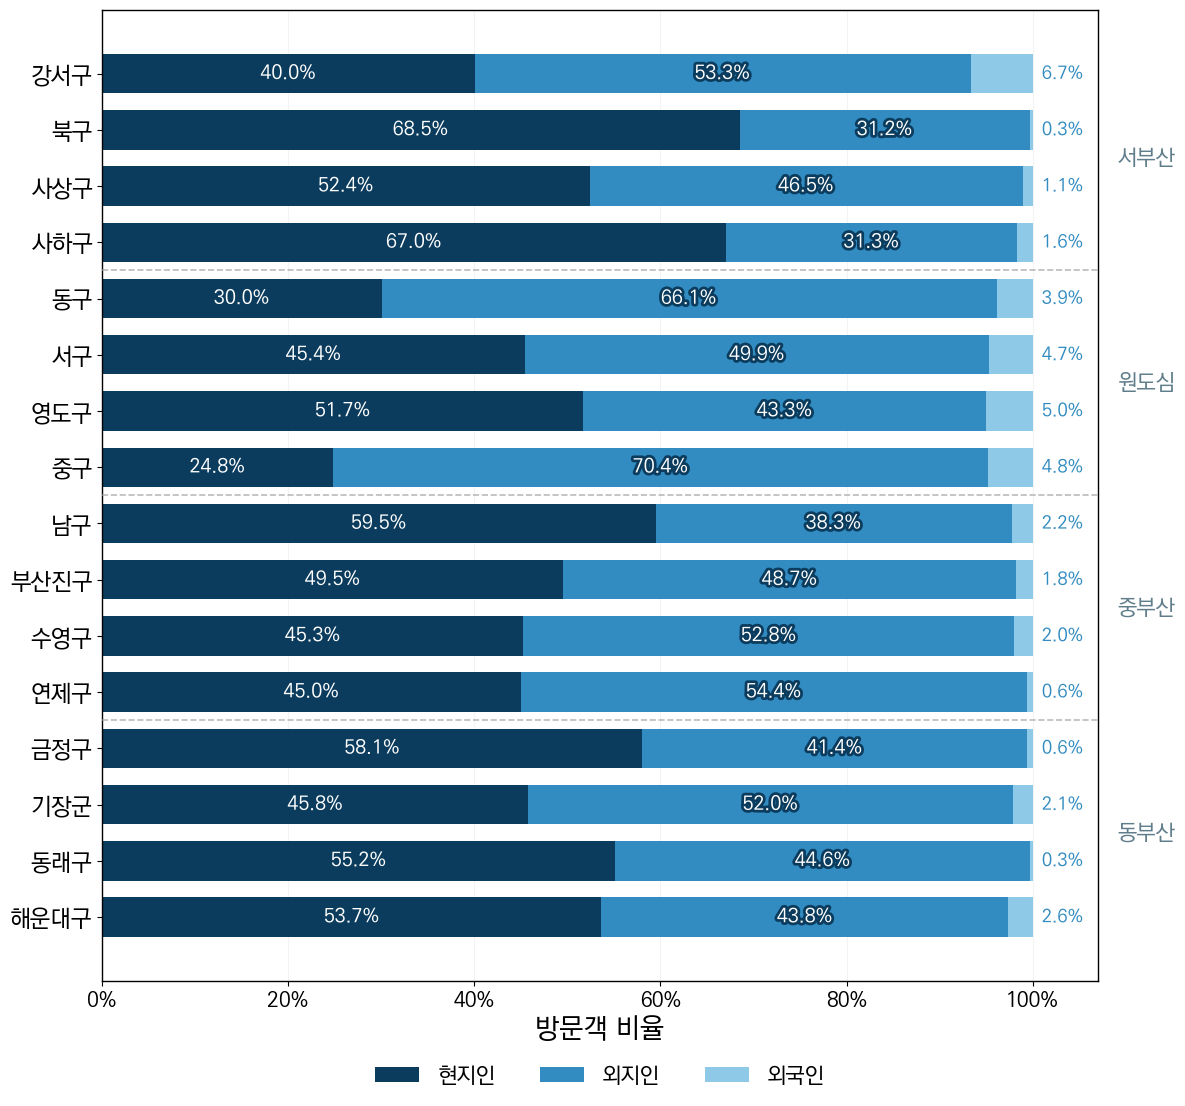

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import PercentFormatter


# =========================================================
# 1. 4개 권역 설정
# =========================================================

region_map = {
    # 원도심
    "중구": "원도심",
    "동구": "원도심",
    "서구": "원도심",
    "영도구": "원도심",

    # 중부산
    "남구": "중부산",
    "부산진구": "중부산",
    "수영구": "중부산",
    "연제구": "중부산",

    # 서부산
    "강서구": "서부산",
    "북구": "서부산",
    "사상구": "서부산",
    "사하구": "서부산",

    # 동부산
    "금정구": "동부산",
    "기장군": "동부산",
    "동래구": "동부산",
    "해운대구": "동부산",
}


# =========================================================
# 2. 권역 순서
# =========================================================

region_order = [
    "서부산",
    "원도심",
    "중부산",
    "동부산"
]


# =========================================================
# 3. 2025년 데이터
# =========================================================

plot_df = (
    df[df["연도"] == 2025]
    .copy()
)


# =========================================================
# 4. 권역 추가
# =========================================================

plot_df["권역"] = plot_df["구군"].map(region_map)

plot_df["권역"] = pd.Categorical(
    plot_df["권역"],
    categories=region_order,
    ordered=True
)


# =========================================================
# 5. 권역별 → 구군 가나다순
# =========================================================

plot_df = (
    plot_df
    .sort_values(
        ["권역", "구군"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)


# =========================================================
# 6. 전체 방문객 수
# =========================================================

plot_df["전체"] = (
    plot_df["현지인"]
    + plot_df["외지인"]
    + plot_df["외국인"]
)


# =========================================================
# 7. 방문객 구성비 계산
# =========================================================

plot_df["현지인_pct"] = (
    plot_df["현지인"]
    / plot_df["전체"]
    * 100
)

plot_df["외지인_pct"] = (
    plot_df["외지인"]
    / plot_df["전체"]
    * 100
)

plot_df["외국인_pct"] = (
    plot_df["외국인"]
    / plot_df["전체"]
    * 100
)


# =========================================================
# 8. 그래프
# =========================================================

fig, ax = plt.subplots(
    figsize=(13, 11)
)


# =========================================================
# 9. 색상
# =========================================================

colors = {
    "현지인": "#0B3C5D",
    "외지인": "#328CC1",
    "외국인": "#8EC9E8"
}


# =========================================================
# 10. 누적 막대 - 현지인
# =========================================================

ax.barh(
    plot_df["구군"],
    plot_df["현지인_pct"],

    color=colors["현지인"],
    label="현지인",

    height=0.7
)


# =========================================================
# 11. 누적 막대 - 외지인
# =========================================================

ax.barh(
    plot_df["구군"],
    plot_df["외지인_pct"],

    left=plot_df["현지인_pct"],

    color=colors["외지인"],
    label="외지인",

    height=0.7
)


# =========================================================
# 12. 누적 막대 - 외국인
# =========================================================

ax.barh(
    plot_df["구군"],
    plot_df["외국인_pct"],

    left=(
        plot_df["현지인_pct"]
        + plot_df["외지인_pct"]
    ),

    color=colors["외국인"],
    label="외국인",

    height=0.7
)


# =========================================================
# 13. 네온 느낌 텍스트 효과
# =========================================================

neon_effect = [
    pe.Stroke(
        linewidth=4,
        foreground="#0B3C5D"
    ),
    pe.Normal()
]


# =========================================================
# 14. 비율 레이블
# =========================================================

for i in range(len(plot_df)):

    local = plot_df.loc[i, "현지인_pct"]
    domestic = plot_df.loc[i, "외지인_pct"]
    foreign = plot_df.loc[i, "외국인_pct"]


    # -----------------------------------------------------
    # 현지인
    # -----------------------------------------------------

    ax.text(
        local / 2,
        i,

        f"{local:.1f}%",

        ha="center",
        va="center",

        fontsize=14,
        fontweight="bold",

        color="white",

        path_effects=neon_effect,

        zorder=5
    )


    # -----------------------------------------------------
    # 외지인
    # -----------------------------------------------------

    ax.text(
        local + domestic / 2,
        i,

        f"{domestic:.1f}%",

        ha="center",
        va="center",

        fontsize=14,
        fontweight="bold",

        color="white",

        path_effects=neon_effect,

        zorder=5
    )


    # -----------------------------------------------------
    # 외국인
    # 오른쪽 바깥
    # -----------------------------------------------------

    ax.text(
        101,
        i,

        f"{foreign:.1f}%",

        ha="left",
        va="center",

        fontsize=13,
        fontweight="bold",

        color="#328CC1",

        path_effects=[
            pe.Stroke(
                linewidth=3,
                foreground="white"
            ),
            pe.Normal()
        ],

        zorder=5
    )


# =========================================================
# 15. 위 → 아래
#
# 서부산
# 원도심
# 중부산
# 동부산
# =========================================================

ax.invert_yaxis()


# =========================================================
# 16. 권역 구분선 + 오른쪽 권역명
# =========================================================

for region in region_order:

    idx = plot_df.index[
        plot_df["권역"] == region
    ].tolist()

    if not idx:
        continue

    start = min(idx)
    end = max(idx)


    # -----------------------------------------------------
    # 권역 사이 점선
    # -----------------------------------------------------

    if start > 0:

        ax.axhline(
            y=start - 0.5,

            color="#9E9E9E",

            linewidth=1.2,
            linestyle="--",

            alpha=0.7,

            zorder=6
        )


    # -----------------------------------------------------
    # 권역 중앙 위치
    # -----------------------------------------------------

    center = (start + end) / 2


    # -----------------------------------------------------
    # 오른쪽 권역명
    # -----------------------------------------------------

    ax.text(
        1.02,
        center,

        region,

        transform=ax.get_yaxis_transform(),

        ha="left",
        va="center",

        fontsize=16,
        fontweight="bold",

        color="#607D8B",

        zorder=10
    )


# =========================================================
# 17. X축
# =========================================================

ax.set_xlim(
    0,
    107
)

ax.set_xlabel(
    "방문객 비율",
    fontsize=20,
    fontweight="bold"
)

ax.set_ylabel("")


ax.set_xticks([
    0,
    20,
    40,
    60,
    80,
    100
])

ax.xaxis.set_major_formatter(
    PercentFormatter(100)
)


# =========================================================
# 18. 틱
# =========================================================

ax.tick_params(
    axis="x",
    labelsize=15
)

ax.tick_params(
    axis="y",
    labelsize=17
)


# =========================================================
# 19. 범례
# =========================================================

ax.legend(
    fontsize=16,

    frameon=False,

    loc="lower center",
    bbox_to_anchor=(0.5, -0.13),

    ncol=3
)


# =========================================================
# 20. 보조선
# =========================================================

ax.grid(
    axis="x",
    alpha=0.15
)

ax.set_axisbelow(True)


# =========================================================
# 21. 바깥 테두리 유지
# =========================================================

for spine in ax.spines.values():

    spine.set_visible(True)
    spine.set_linewidth(1.0)


# =========================================================
# 22. 레이아웃
#
# 오른쪽 권역명 공간 확보
# =========================================================

plt.tight_layout(
    rect=[0, 0, 0.92, 1]
)


# =========================================================
# 23. 저장
# =========================================================

plt.savefig(
    "2025_구군별_방문객_구성비_4권역.png",

    dpi=300,
    bbox_inches="tight"
)


plt.show()